<a href="https://colab.research.google.com/github/davide6556/AML/blob/main/Copia_di_AMLAdv_HandsOn_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

 The **Fluorescent Neuronal Cells v1 dataset (FNC v1)** [(Clissa et al., 2021)](http://amsacta.unibo.it/6706/) is a collection of 283 high-resolution photos (1200x1600 pixels) and their corresponding pixel-level annotations.
  
These images depict rodent brain slices photographed with a fluorescence microscope.
The neurons of interest appear highlighted as yellow spots of various shapes, sizes and colors, placed on a background that is also variable but generally darker.

In this notebook we will explore our dataset, trying to understand its characteristics and planning the necessary steps for its analysis.

## Data download

First, let's download the data from the [official repository ](http://amsacta.unibo.it/6706/):

In [ ]:
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = Path("/content/drive/MyDrive/fluocells/fluocells_data1")
CODE_PATH = Path("/content/drive/MyDrive/fluocells/fluocells_code")

import sys
sys.path.insert(0, str(CODE_PATH))

# !unzip /content/drive/MyDrive/<path-to>/fluocells.zip
# !mkdir /content/drive/MyDrive/fluocells_data1
# !unzip /content/drive/MyDrive/fluocells/fluocells.zip -d /content/drive/MyDrive/fluocells_data1

ValueError: mount failed

<div class="alert alert-block alert-info">

Download should take 5-10 minutes depending on connection speed.

</div>

<div class="alert alert-block alert-warning">

In case of problems, try to manually download data from link and put them in a folder named `fluocells_data`.

</div>



> Once downloaded, data should stay in a folder named `fluocells_data`.

In particular, images will be *png* files at path `all_images/images`, while corresponding masks will be in the folder `all_masks/masks`.

In practice, we will use images as input data and masks as *labels* for supervision for our training, that is: examples of desired outputs we want our model to learn from.

<div class="alert alert-block alert-info">

> **Note:** *label*, *annotation*, *mask* or *ground-truth* are all terms used in ML jargon to refer to **desired output a model should learn from** in a supervised learning framework. We will use these terms interchangeably to refer to the same concept.
</div>

In [ ]:
!sudo apt-get install -q tree
!tree -L 2 /content/drive/MyDrive/fluocells/fluocells_data1

Reading package lists...
Building dependency tree...
Reading state information...
tree is already the newest version (2.0.2-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/content/drive/MyDrive/fluocells/fluocells_data1
├── all_images
│   ├── images
│   └── LICENSE.txt
├── all_masks
│   ├── LICENSE.txt
│   └── masks
└── README.md

4 directories, 3 files


## Sample Images

First, we can visualize what some of these images look like.
We can use different libraries, each with some peculiarities.

For now we will use [scikit-image](https://scikit-image.org/docs/dev/install.html) to import the images and [matplotlib](https://matplotlib.org/) to display them, but other alternatives are equally valid.


> Try exploring the dataset independently
> - you just need to change sample_img_names by inserting the names of the images you want to visualize!


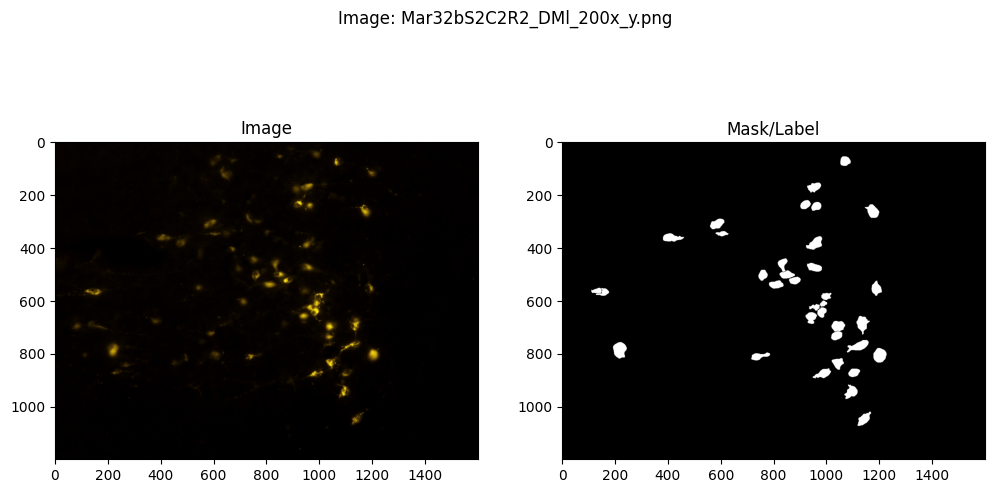

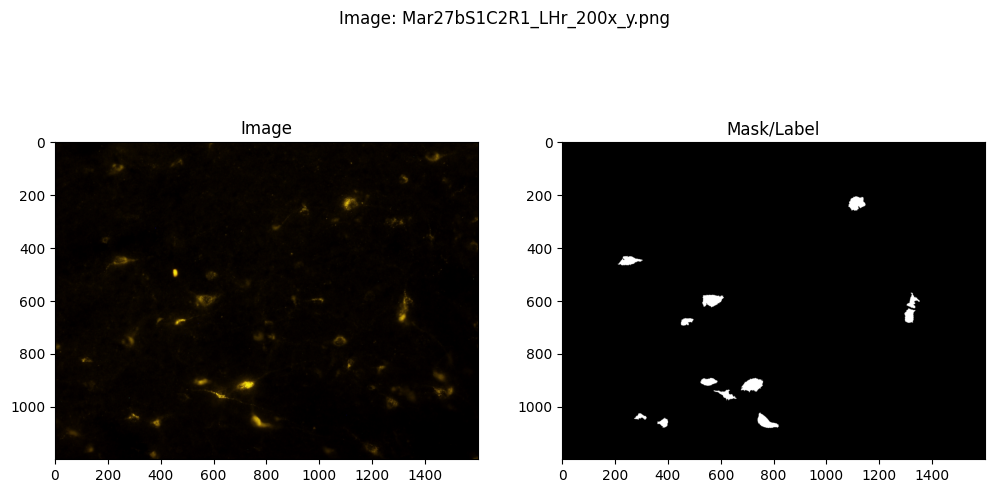

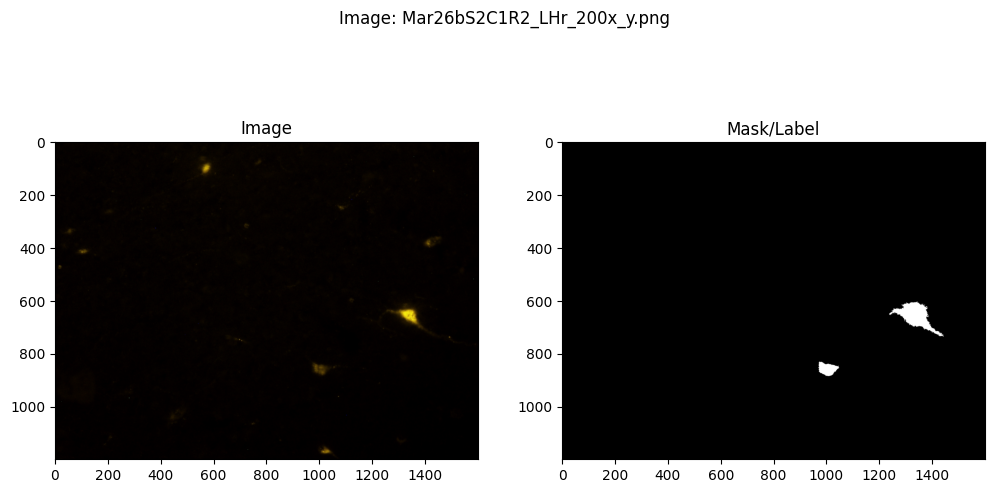

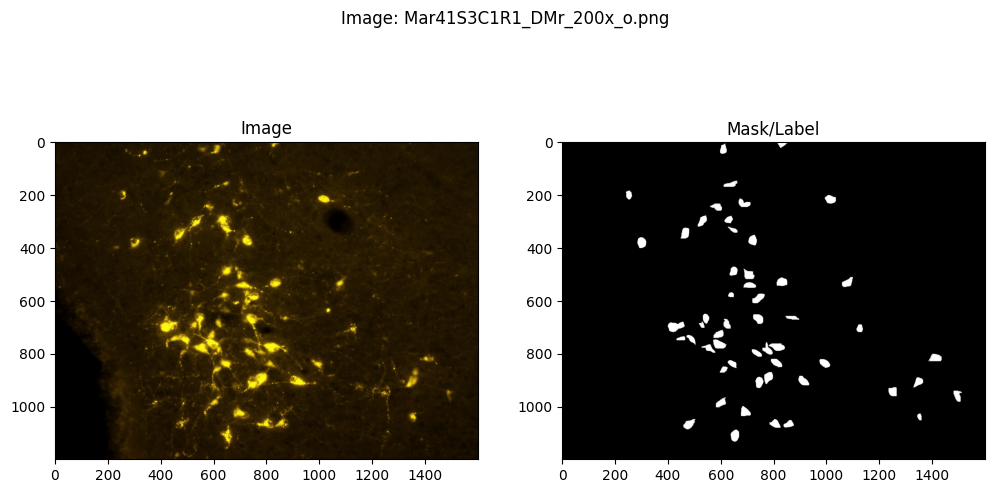

In [ ]:
import skimage.io as io
from pathlib import Path
import matplotlib.pyplot as plt

IMG_PATH = DATA_PATH / 'all_images/images'
MASK_PATH = DATA_PATH / 'all_masks/masks'

sample_img_names = ['Mar32bS2C2R2_DMl_200x_y.png', 'Mar27bS1C2R1_LHr_200x_y.png',
                    'Mar26bS2C1R2_LHr_200x_y.png', 'Mar41S3C1R1_DMr_200x_o.png']

for img_name in sample_img_names:
    img = io.imread(IMG_PATH / img_name)
    mask = io.imread(MASK_PATH / img_name, as_gray=True)

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f'Image: {img_name}')
    ax[0].imshow(img)
    ax[0].set_title('Image')
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title('Mask/Label')
    plt.show()

> The masks are nothing more than a "legend" where each pixel is associated with the color:
>
> **white** if it belongs to a cell
>
> **black** if it belongs to the background.

## Image Format

After a first inspection at a purely visual level, it is always very useful to check some more quantitative characteristics.

First, we can analyze the shape and encoding of the images.



# What do you expect?
- shape
- type
- values


In [ ]:
import numpy as np
for img_name in sample_img_names:
    img = io.imread(IMG_PATH / img_name)
    mask = io.imread(MASK_PATH / img_name, as_gray=True)

    print(f'\n\n - {img_name}\n\nImage\ntype: {type(img)} - {img.dtype}\nshape: {img.shape}')
    print(f'\nMask\ntype: {type(mask)} - {mask.dtype}\nshape: {mask.shape}\nunique values: {np.unique(mask)}')



 - Mar32bS2C2R2_DMl_200x_y.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - uint16
shape: (1200, 1600)
unique values: [    0 65535]


 - Mar27bS1C2R1_LHr_200x_y.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - uint16
shape: (1200, 1600)
unique values: [    0 65535]


 - Mar26bS2C1R2_LHr_200x_y.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - uint16
shape: (1200, 1600)
unique values: [    0 65535]


 - Mar41S3C1R1_DMr_200x_o.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - uint16
shape: (1200, 1600)
unique values: [    0  3317  6636  9749  9807 11367 11382 11675 11750 11879 12227 12833
 13235 13472 13547 13583 13731 15124 15380 16388 16645 16684 16809 16939
 17148 17803 17838 17967 18131 18185 18189 18240 18349 18389 18519 18553
 18662 18782 189

In [ ]:
img.min(), img.max()

(np.uint8(0), np.uint8(255))

The **images** are naturally represented through **RGB encoding**, i.e. each pixel is expressed as a combination of 3 colors: red (R), green (G) and blue (B), respectively.

In particular, scikit image returns *numpy arrays* having a shape (H, W, C) where H determines the height, W the width and C the number of channels for color encoding.
In our case, the images are 1200 x 1600 pixels (px), with 3 channels for red, green and blue values.

The **masks**, instead, are read with **grayscale encoding** thanks to the addition of the `as_gray=True` attribute in `skimage.io.imread`.
In particular, each mask has the same number of pixels as the corresponding image, and each pixel is filled with a color depending on the class (cell or background) to which it belongs.

This is sufficient since we need binary masks, i.e. with only two distinct values, one for the background (black) and one for the cells (white).


Info block 1:
<div class="alert alert-block alert-info">
The masks are in *type uint16*, so the corresponding grayscale goes from *0 ⟶ black* to *65535 ⟶ white*. In the following we will see how to convert them to other formats more convenient for our analyses.
</div>

Info block 2:
<div class="alert alert-block alert-warning">
Not all masks are already binarized (see list of unique values). Furthermore, the annotation process is subject to occasional errors that involve the presence of artifacts of various kinds (e.g. presence of isolated pixels labeled as cells). For these reasons, it will be necessary to do some cleaning first.
</div>


## Mask Cleaning

The data cleaning operations we will perform are 2:

- **Binarization** (also called *thresholding*): all pixels with values *>0* will be assigned value *255* and will therefore be considered as cells

- **Small object removal**: all cells with area `<150` pixels will be discarded

The resulting masks will then be overwritten on the original ones.

In [ ]:
import skimage
skimage.__version__

'0.25.2'

In [ ]:
from tqdm import tqdm
from skimage.morphology import remove_small_objects
from skimage import measure


def remove_noise_from_masks(masks_path, out_path, min_obj_size=150, connectivity=1):
    for p in tqdm([*masks_path.iterdir()]):
        try:
          mask = io.imread(p, as_gray=True)
        except OSError:
          print(f"\n\nCould not open image: {p}. File format not supported or corrupted file")

        # thresholding
        mask[mask > 0] = 255
        # remove small objects
        label = measure.label(mask, connectivity=connectivity)
        label = remove_small_objects(label.astype(bool), min_size=min_obj_size,
                             connectivity=connectivity)
        label[label > 0] = 255

        # fix filename and change format
        out_path = out_path if out_path.name == "masks" else out_path / 'masks'
        out_path.mkdir(parents=True, exist_ok=True)

        # filename = p.name.split('.')[0] + '.png'
        # outname = str(out_path / fix_mask_filename(filename))
        outname = str(out_path / p.name)
        plt.imsave(fname=outname, arr=label, cmap='gray')
    return


remove_noise_from_masks(MASK_PATH, MASK_PATH)

100%|██████████| 283/283 [01:05<00:00,  4.29it/s]


In [ ]:
import numpy as np
for img_name in sample_img_names:
    img = io.imread(IMG_PATH / img_name)
    mask = io.imread(MASK_PATH / img_name, as_gray=True)

    print(
        f'\n\n - {img_name}\n\nImage\ntype: {type(img)} - {img.dtype}\nshape: {img.shape}')
    print(
        f'\nMask\ntype: {type(mask)} - {mask.dtype}\nshape: {mask.shape}\nunique values: {np.unique(mask)}')



 - Mar32bS2C2R2_DMl_200x_y.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - float64
shape: (1200, 1600)
unique values: [0. 1.]


 - Mar27bS1C2R1_LHr_200x_y.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - float64
shape: (1200, 1600)
unique values: [0. 1.]


 - Mar26bS2C1R2_LHr_200x_y.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - float64
shape: (1200, 1600)
unique values: [0. 1.]


 - Mar41S3C1R1_DMr_200x_o.png

Image
type: <class 'numpy.ndarray'> - uint8
shape: (1200, 1600, 3)

Mask
type: <class 'numpy.ndarray'> - float64
shape: (1200, 1600)
unique values: [0. 1.]


## Cell Characteristics

As anticipated, the cells present a great variety of shapes, sizes and tones. In this section we will analyze their characteristics in more detail.

In [ ]:
import pandas as pd
from tqdm.auto import tqdm
from skimage import measure

def compute_masks_stats(masks_path):
    """
    Read ground-truth masks and compute metrics for cell counts and shapes
    :param masks_path: Pathlib.Path() to masks folder
    :return:
    """
    paths = [*masks_path.iterdir()]
    data = []
    for idx_image, p in tqdm(enumerate(paths), total=len(paths)):
        mask = io.imread(p, as_gray=True)
        skimage_label, n_objs = measure.label(
            mask, connectivity=1, return_num=True)

        # add one row per object
        for idx_obj, obj in enumerate(measure.regionprops(skimage_label)):
            data.append([
                p.name.split('.')[0],
                int(n_objs),
                idx_obj,
                int(obj.area),
                obj.minor_axis_length,
                obj.major_axis_length,
                obj.equivalent_diameter,
                obj.feret_diameter_max,
            ])

        # add empty row in case image has no objects
        if n_objs == 0:
            data.append([
                p.name.split('.')[0],
                int(n_objs),
                None, None, None, None, None, None,
            ])

    # store stats in dataframe
    stats_df = pd.DataFrame(data=data,
                            columns=[
                                'img_name',
                                'n_cells',
                                'cell_id',
                                'area',
                                'min_axis_length',
                                'max_axis_length',
                                'equivalent_diameter',
                                'feret_diameter_max',
                            ])
    # save stats dataframe
    stats_df.round(4).to_csv(masks_path.parent / 'stats_df.csv', index=False)
    return stats_df


stats_df = compute_masks_stats(MASK_PATH)
stats_df

  0%|          | 0/283 [00:00<?, ?it/s]

,img_name,n_cells,cell_id,area,min_axis_length,max_axis_length,equivalent_diameter,feret_diameter_max
0,37_y,5,0.0,3817.0,59.228119,91.399640,69.713380,106.920531
1,37_y,5,1.0,2054.0,37.143873,71.430156,51.139359,72.801099
2,37_y,5,2.0,3049.0,50.084990,86.287544,62.306560,96.798760
3,37_y,5,3.0,1828.0,41.788569,57.424294,48.243983,59.363288
4,37_y,5,4.0,1916.0,36.596274,70.408496,49.391568,77.466122
...,...,...,...,...,...,...,...,...
2226,MAR55S3C2R2_VLPAGR_20_o,20,15.0,650.0,24.681161,46.492502,28.768137,46.324939
2227,MAR55S3C2R2_VLPAGR_20_o,20,16.0,419.0,18.732508,29.619837,23.097346,30.083218
2228,MAR55S3C2R2_VLPAGR_20_o,20,17.0,1012.0,28.243983,48.854582,35.895939,54.708317
2229,MAR55S3C2R2_VLPAGR_20_o,20,18.0,523.0,23.840950,28.742301,25.805121,30.083218


### Summary table

In [ ]:
qq = [0.1, 0.25, 0.5, 0.75, 0.9]

summary = stats_df.describe(percentiles=qq).round(4)
summary

,n_cells,cell_id,area,min_axis_length,max_axis_length,equivalent_diameter,feret_diameter_max
count,2231.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000,2179.0000
mean,27.8077,13.7357,1511.6925,33.6400,56.6111,41.3577,61.9104
std,22.4573,15.2749,1156.4980,12.7576,24.0548,14.6418,28.7734
min,0.0000,0.0000,151.0000,8.7011,14.7281,13.8658,16.2788
10%,4.0000,0.0000,496.8000,19.8306,32.4127,25.1505,34.1321
25%,7.0000,2.0000,764.5000,24.5290,40.5369,31.1992,42.7200
50%,21.0000,7.0000,1170.0000,31.3391,51.3194,38.5965,54.9181
75%,51.0000,21.0000,1886.0000,40.3317,67.4972,49.0034,74.1215
90%,60.0000,38.2000,2915.0000,50.2636,86.9102,60.9220,96.8184
max,69.0000,68.0000,9360.0000,97.4496,205.7924,109.1674,257.3888


In total we have **2204 cells** distributed across 2256 images, while the remaining 52 do not contain any cells.

From the percentiles reported in the table, it is possible to notice how there is a great variety of shapes and sizes.

Furthermore, the quantity of cells present in each image also varies from zero or a few units to several dozens.

Below are some graphs to visually inspect the distributions of the most significant characteristics.

INFO BOX 1:
<div class="alert alert-block alert-info">
    
**Feret diameter:** maximum length between points on the same convex contour. For more information: [[1]](https://en.wikipedia.org/wiki/Feret_diameter), [[2]](https://it.wikipedia.org/wiki/Diametro_sferico_equivalente), [[3]](https://scikit-image.org/docs/0.18.x/api/skimage.measure.html?highlight=feret)
    
</div>

INFO BOX 2:
<div class="alert alert-block alert-info">
    
The difference in count between n_cells and the other columns is due to the 52 images without cells.
    
</div>

### Features distributions

In [ ]:
import plotly.graph_objects as go


layout = {
    'template': "plotly_white",
    'paper_bgcolor': 'rgba(0,0,0,0)',
    'plot_bgcolor': 'rgba(0,0,0,0)',
    'title': {
        'x': 0.5, 'xanchor': 'center'
    },
    'font': dict(
        family="Helvetica",
        size=12,
    ),
    'showlegend': False,
    'autosize': False,
    'width': 440,
    'height': 440,
    'margin': dict(l=0, r=0, t=0, b=0),
}
colors = ["#FB8537", "#188BC9"]


fig = go.Figure(layout=layout)
resolution = 1

viol = fig.add_trace(
    go.Violin(y=stats_df['feret_diameter_max']/resolution,
              box_visible=True, line_color='black',
              meanline_visible=True, fillcolor=colors[1], opacity=0.6,
              spanmode='hard',
              ),
)

_ = fig.update_yaxes(title='maximum Feret diameter (pixels)')
_ = fig.update_xaxes(visible=False)

fig.show()

For the maximum Feret diameter, we have mean and median between 55 and 60 pixels (**55 and 62, respectively**). The distribution is concentrated on low values (**interquartile range between 42 and 74 pixels**), with a prolonged tail up to over 200 pixels.

In [ ]:
fig = go.Figure(layout=layout)

viol = fig.add_trace(
    go.Violin(y=stats_df['area'] / resolution**2,
              box_visible=True, line_color='black',
              meanline_visible=True, fillcolor=colors[0], opacity=0.6,
              spanmode='hard',
              ),
)

_ = fig.update_yaxes(title='area (pixels<sup>2</sup>)')
_ = fig.update_xaxes(visible=False)

fig.show()

Regarding the area instead, we have **mean and median between 1170 and 1511 pixels**. Also in this case the distribution is concentrated on low values (**interquartile range between 764 and 1886 pixels**), with a prolonged tail up to over 6000 pixels.

In [ ]:
fig = go.Figure(layout=layout)

_ = fig.add_trace(go.Histogram(x=stats_df['n_cells'], nbinsx=70,
                               marker_color="#98E2C6", opacity=0.6,
                               )
                  )
_ = fig.update_yaxes(title='# images')
_ = fig.update_xaxes(title='# cells')

fig.show()

Finally, the images present about **28 cells on average (median equal to 21)**.
The distribution is multimodal, with a **first peak below 20 units** followed by groups of images with an increasing number of cells, **up to several dozens**.

# Exercise!

Explore class imbalance for this task

## Colorspace

By colorspace we mean the encoding of color information. Indeed, we can represent the information contained in the colors of the image in different ways, which will have slightly different properties.

> Choosing an appropriate colorspace could make our problem easier to solve.

In [ ]:
import cv2
import numpy as np


def plot_3Dcolorspace(img, colorspace=['RGB', 'HSV'], img_name=None):
    '''Plot pixel into 3D colorspace.

    Keyword arguments:
    img -- array with rgb image
    colorspace -- list with names of the colorspace to consider; only rgb and hsv supported
    img_name -- name of the image to use as title of the plot

    Return: fig
    '''
    from matplotlib import colors
    elev, azim = 25, 45
    ls = 2

    # store pixel colors into a list
    pixel_colors = img.reshape((np.shape(img)[0]*np.shape(img)[1], 3))
    norm = colors.Normalize(vmin=-1., vmax=1.)
    norm.autoscale(pixel_colors)
    pixel_colors = norm(pixel_colors).tolist()

    # print 3D scatterplot of pixels into the appropriate colorspace

    # RGB
    fig = plt.figure(figsize=(15, 8))
    axis = fig.add_subplot(1, 2, 1, projection="3d")
    r, g, b = cv2.split(img)
    axis.scatter(r.flatten(),
                 g.flatten(),
                 b.flatten(),
                 facecolors=pixel_colors, marker=".")
    axis.view_init(elev, azim)
    axis.set_xlabel("\n Red ", linespacing=ls)
    axis.set_ylabel("\nGreen", linespacing=ls)
    axis.set_zlabel("\n Blue", linespacing=ls)
    plt.title("{} colorspace".format(colorspace[0]))

    # HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv_img)
    axis = fig.add_subplot(1, 2, 2, projection="3d")
    axis.scatter(h.flatten(), s.flatten(), v.flatten(),
                 facecolors=pixel_colors, marker=".")
    axis.view_init(elev, azim)
    axis.set_xlabel("\n Hue ", linespacing=ls)
    axis.set_ylabel("\nSaturation", linespacing=ls)
    axis.set_zlabel("\nValue", linespacing=ls)
    plt.title("{} colorspace".format(colorspace[1]))
    if img_name:
        fig.suptitle(img_name)
    plt.show()
    return fig

  0%|          | 0/4 [00:00<?, ?it/s]

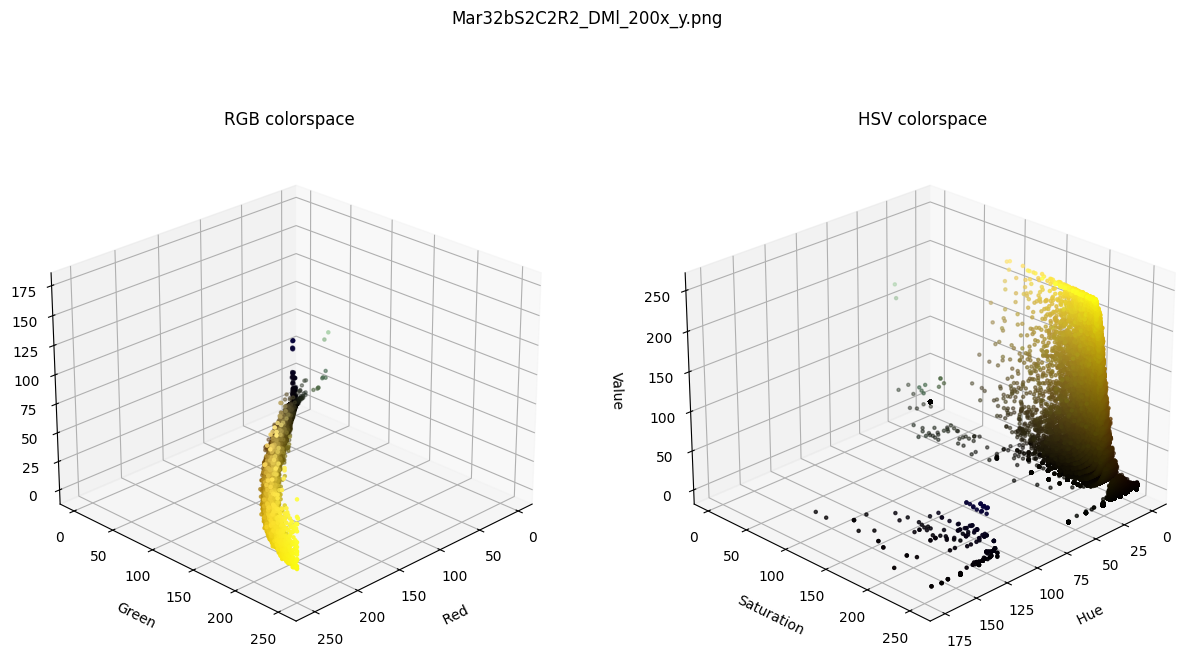

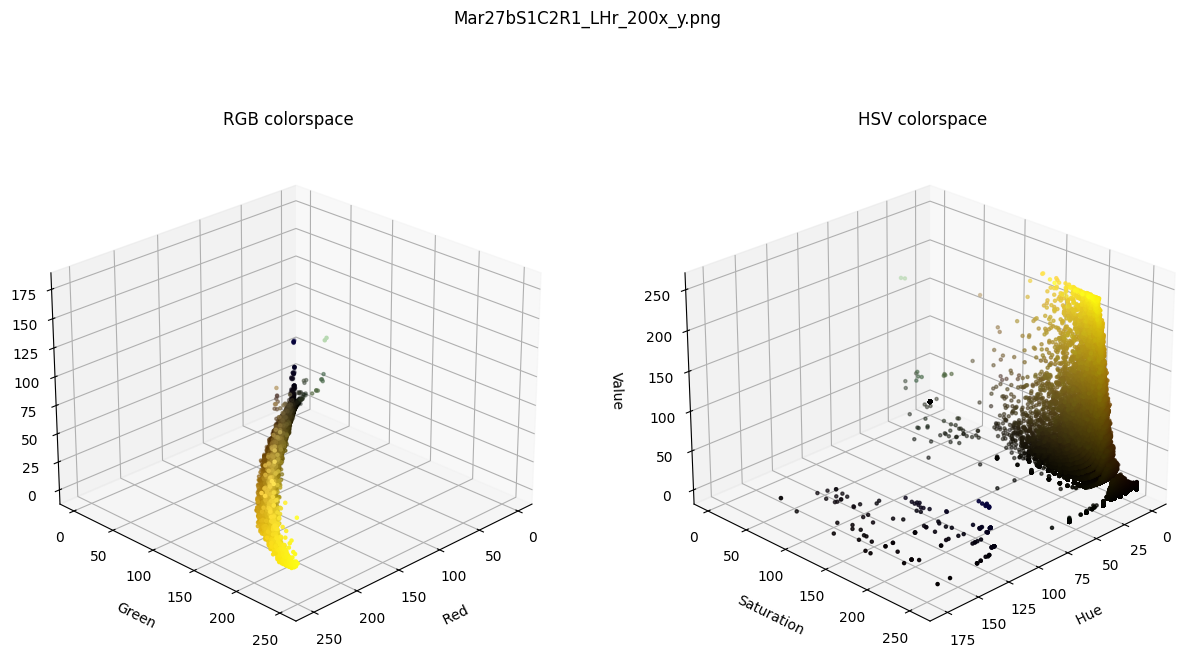

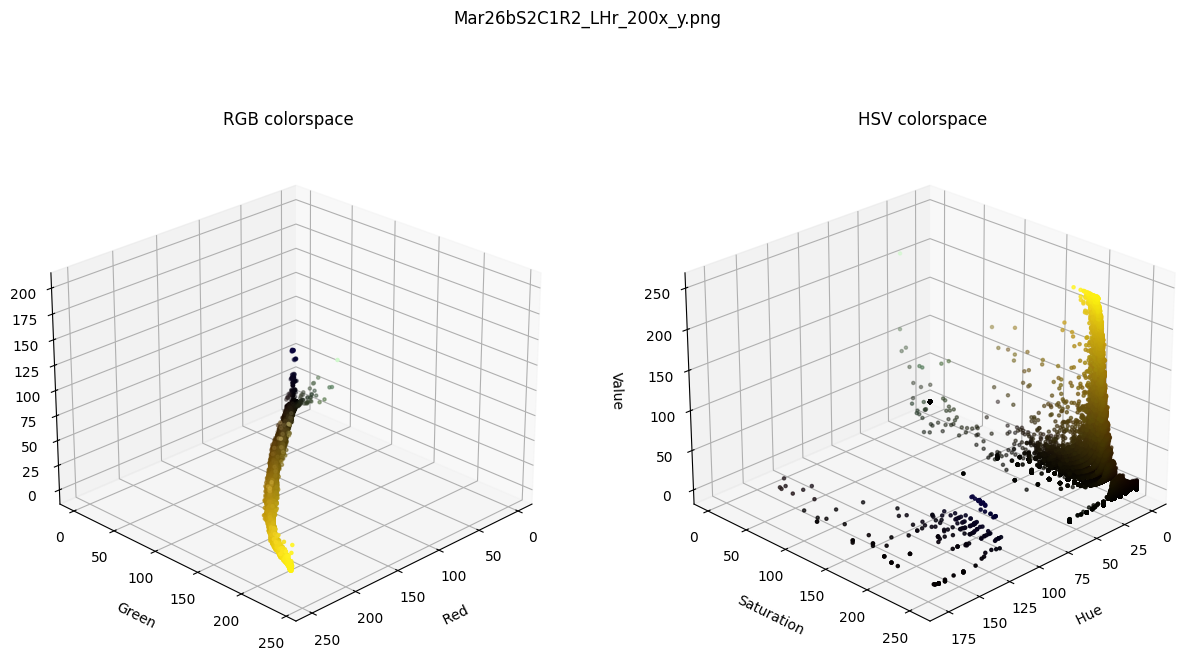

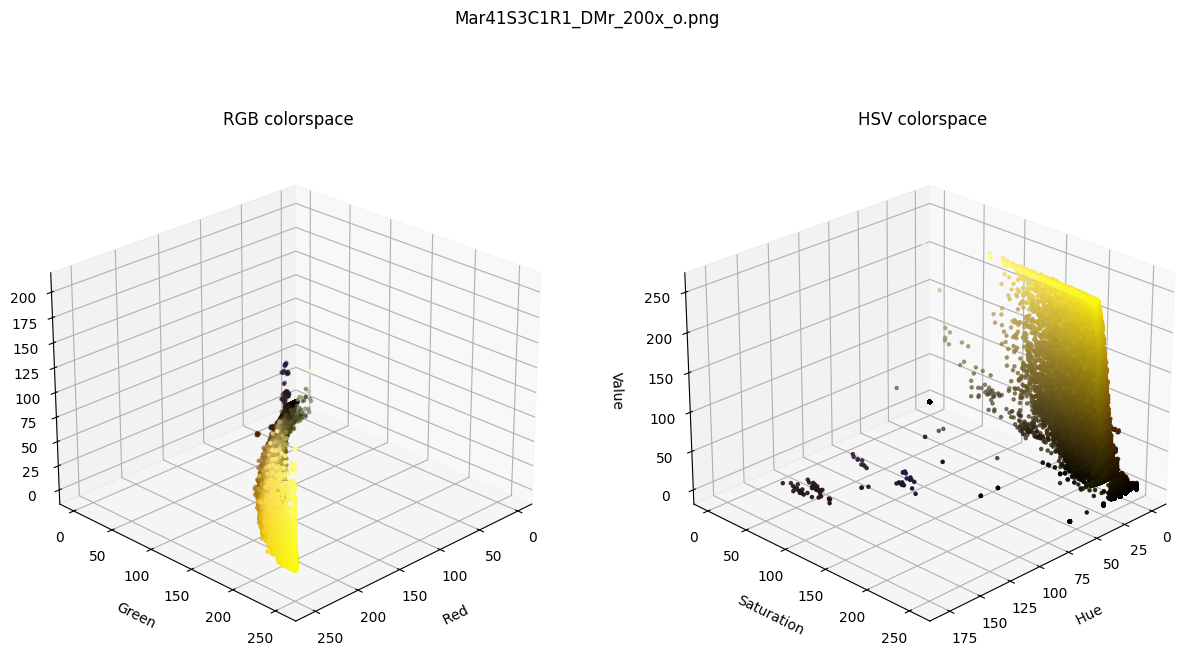

CPU times: user 10min 51s, sys: 7.63 s, total: 10min 59s
Wall time: 11min 7s


In [ ]:
%%time

for img_name in tqdm(sample_img_names):
    img = io.imread(IMG_PATH / img_name)
    plot_3Dcolorspace(img, img_name=img_name)

# Can you guess why RGB point clouds have that shape?

Any idea?

The **RGB encoding** does not seem to be an optimal representation in our case. **The color tones are in fact concentrated in the green/red plane**.

Moreover, the pixels seem almost to be aligned along the bisector of this plane, suggesting that a three-dimensional colorspace is not necessary and that probably a single-dimensional alternative could be sufficient.

Info block 1:

This confirms the visual impression that the images are in fact **shades of yellow**, which is chromatically expressed as a combination of red and green.

The *HSV encoding* instead shows a greater distribution of pixels across the 3 dimensions, suggesting that probably **other colorspaces could make it easier to separate cell from background pixels.**

Info block 2:

In the following we will exploit these observations to try to obtain the best possible encoding for our problem.

**Sample image**

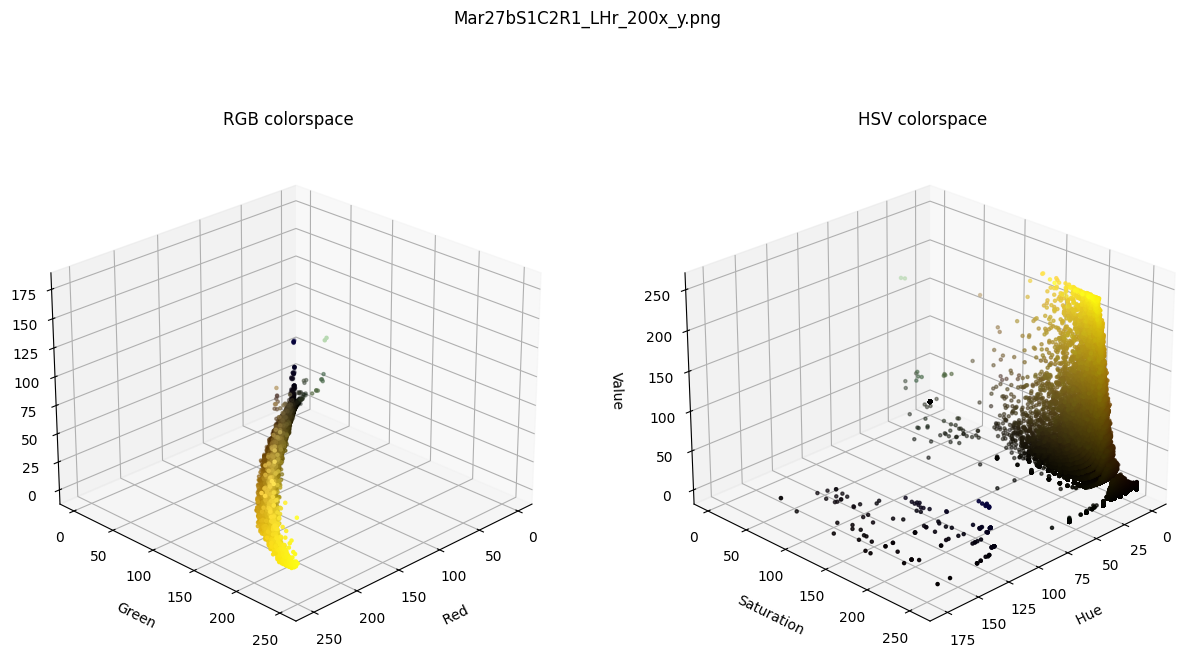